# CNN Baseline

This notebook uses the shared preprocessing notebook before defining the model.

In [1]:
from pathlib import Path
from IPython import get_ipython
import copy
import json
import os
import time
from dataclasses import asdict, dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

preprocessing_notebook = Path("shared/preprocessing.ipynb")
if not preprocessing_notebook.exists():
    preprocessing_notebook = Path("../shared/preprocessing.ipynb")
get_ipython().run_line_magic("run", str(preprocessing_notebook))

evaluation_notebook = Path("shared/evaluate.ipynb")
if not evaluation_notebook.exists():
    evaluation_notebook = Path("../shared/evaluate.ipynb")
get_ipython().run_line_magic("run", str(evaluation_notebook))

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DEFAULT_DATA_DIR}")

Using device: cuda
Project root: c:\Users\Duvini\Documents\GitHub\Wildfire-Spread-Prediction-from-Satellite-Imagery
Dataset directory: c:\Users\Duvini\Documents\GitHub\Wildfire-Spread-Prediction-from-Satellite-Imagery\data


# Model Architecture

In [2]:
class ConvBlock(nn.Module):
    """Conv -> BatchNorm -> ReLU, repeated twice."""

    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [3]:
class CNNBaseline(nn.Module):
    """Simple, stable CNN baseline for highly imbalanced wildfire segmentation.

    This is intentionally lighter than a full encoder-decoder and avoids the
    instability that can come from a very wide, deep CNN on a rare-positive task.
    It still captures local spatial structure while remaining easy to train and
    interpret under the assignment rubric.
    """

    def __init__(self, in_channels: int = 12, base_channels: int = 32, dropout: float = 0.15):
        super().__init__()
        c = base_channels

        self.enc1 = ConvBlock(in_channels, c)
        self.enc2 = ConvBlock(c, c * 2)
        self.enc3 = ConvBlock(c * 2, c * 3)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(c * 3, c * 4, dropout=dropout)

        self.up3 = nn.ConvTranspose2d(c * 4, c * 3, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(c * 3, c * 3, dropout=dropout)

        self.up2 = nn.ConvTranspose2d(c * 3, c * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(c * 2, c * 2)

        self.up1 = nn.ConvTranspose2d(c * 2, c, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(c, c)

        self.out_conv = nn.Conv2d(c, 1, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        e3 = self.enc3(p2)
        p3 = self.pool(e3)

        b = self.bottleneck(p3)

        d3 = self.dec3(self.up3(b))
        d2 = self.dec2(self.up2(d3))
        d1 = self.dec1(self.up1(d2))
        return self.out_conv(d1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Quick sanity check on architecture shape
_test_model = CNNBaseline(in_channels=NUM_CHANNELS)
_test_out = _test_model(torch.randn(2, NUM_CHANNELS, 64, 64))
assert _test_out.shape == (2, 1, 64, 64), f"Unexpected output shape: {_test_out.shape}"
print(f"Architecture OK. Output shape: {tuple(_test_out.shape)}")
print(f"Total trainable parameters: {count_params(_test_model):,}")
del _test_model, _test_out

Architecture OK. Output shape: (2, 1, 64, 64)
Total trainable parameters: 806,497


# Loss function — masked weighted BCE + focal loss + Dice

In [4]:
def masked_weighted_bce(logits: torch.Tensor, targets: torch.Tensor, mask: torch.Tensor, pos_weight: torch.Tensor) -> torch.Tensor:
    """BCE-with-logits, computed only over pixels where mask == 1."""
    targets_clamped = targets.clamp(0, 1)
    per_pixel = F.binary_cross_entropy_with_logits(
        logits, targets_clamped, pos_weight=pos_weight, reduction="none"
    )
    per_pixel = per_pixel * mask
    return per_pixel.sum() / mask.sum().clamp(min=1.0)


def masked_focal_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    mask: torch.Tensor,
    gamma: float = 2.0,
    alpha: float = 0.75,
) -> torch.Tensor:
    """Focal loss adds a stronger penalty to hard, rare fire pixels."""
    targets_clamped = targets.clamp(0, 1)
    probs = torch.sigmoid(logits)
    pt = probs * targets_clamped + (1.0 - probs) * (1.0 - targets_clamped)
    alpha_t = alpha * targets_clamped + (1.0 - alpha) * (1.0 - targets_clamped)
    focal_term = -alpha_t * (1.0 - pt).pow(gamma) * torch.log(pt.clamp_min(1e-6))
    focal_term = focal_term * mask
    return focal_term.sum() / mask.sum().clamp(min=1.0)


def masked_dice_loss(logits: torch.Tensor, targets: torch.Tensor, mask: torch.Tensor, smooth: float = 1.0) -> torch.Tensor:
    """Soft Dice loss, computed only over valid (masked) pixels."""
    probs = torch.sigmoid(logits) * mask
    targets_clamped = targets.clamp(0, 1) * mask

    intersection = (probs * targets_clamped).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets_clamped.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice.mean()


def combined_loss(
    logits,
    targets,
    mask,
    pos_weight,
    bce_weight: float = 0.55,
    focal_weight: float = 0.25,
    dice_weight: float = 0.20,
    focal_gamma: float = 2.0,
):
    bce = masked_weighted_bce(logits, targets, mask, pos_weight)
    focal = masked_focal_loss(logits, targets, mask, gamma=focal_gamma)
    dice = masked_dice_loss(logits, targets, mask)
    return (
        bce_weight * bce + focal_weight * focal + dice_weight * dice,
        bce.item(),
        focal.item(),
        dice.item(),
    )


# --- Quick correctness test on the loss functions ---
_logits = torch.tensor([[[[5.0, -5.0], [5.0, -5.0]]]])
_targets = torch.tensor([[[[1.0, 0.0], [1.0, -1.0]]]])
_mask = (_targets != -1).float()
_pw = torch.tensor(1.0)
_loss, _bce, _focal, _dice = combined_loss(_logits, _targets, _mask, _pw)
assert _loss.item() < 0.1, f"Expected near-zero loss for confident correct predictions, got {_loss.item()}"
print(f"Loss sanity check OK -> combined={_loss.item():.4f}, bce={_bce:.4f}, focal={_focal:.4f}, dice={_dice:.4f}")

Loss sanity check OK -> combined=0.0045, bce=0.0067, focal=0.0000, dice=0.0040


# Training loop

In [5]:
@dataclass
class TrainConfig:
    lr: float = 3e-4
    weight_decay: float = 1e-4
    batch_size: int = 32
    max_epochs: int = 30
    patience: int = 6
    grad_clip: float = 1.0
    bce_weight: float = 0.55
    focal_weight: float = 0.25
    dice_weight: float = 0.20
    focal_gamma: float = 2.0
    base_channels: int = 32
    dropout: float = 0.15


def train_model(config: TrainConfig, train_loader, val_loader, pos_weight: float, verbose: bool = True):
    model = CNNBaseline(
        in_channels=NUM_CHANNELS,
        base_channels=config.base_channels,
        dropout=config.dropout,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    pw_tensor = torch.tensor(pos_weight, device=device)

    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_iou": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(config.max_epochs):
        model.train()
        train_losses = []
        for x, y, mask in train_loader:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss, _, _, _ = combined_loss(
                logits,
                y,
                mask,
                pw_tensor,
                config.bce_weight,
                config.focal_weight,
                config.dice_weight,
                config.focal_gamma,
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        all_true, all_prob, all_mask = [], [], []
        with torch.no_grad():
            for x, y, mask in val_loader:
                x, y, mask = x.to(device), y.to(device), mask.to(device)
                logits = model(x)
                loss, _, _, _ = combined_loss(
                    logits,
                    y,
                    mask,
                    pw_tensor,
                    config.bce_weight,
                    config.focal_weight,
                    config.dice_weight,
                    config.focal_gamma,
                )
                val_losses.append(loss.item())
                all_true.append(y.cpu().numpy())
                all_prob.append(torch.sigmoid(logits).cpu().numpy())
                all_mask.append(mask.cpu().numpy())

        val_metrics = compute_metrics(
            np.concatenate(all_true), np.concatenate(all_prob), np.concatenate(all_mask)
        )

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_metrics["f1"])
        history["val_iou"].append(val_metrics["iou"])

        scheduler.step(val_loss)

        if verbose:
            print(f"Epoch {epoch+1:3d}/{config.max_epochs} | "
                  f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"val_f1={val_metrics['f1']:.4f} val_iou={val_metrics['iou']:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config.patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1} (no val improvement for {config.patience} epochs)")
                break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

# Train the final model with the chosen configuration

In [6]:
FINAL_CONFIG = TrainConfig(
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=32,
    max_epochs=30,
    patience=6,
    grad_clip=1.0,
    bce_weight=0.55,
    focal_weight=0.25,
    dice_weight=0.20,
    focal_gamma=2.0,
    base_channels=32,
    dropout=0.15,
)

train_loader, val_loader, test_loader, pos_weight = get_dataloaders(
    data_dir=DEFAULT_DATA_DIR,
    batch_size=FINAL_CONFIG.batch_size,
    augment_train=True,
    num_workers=0,
)

start_time = time.perf_counter()
model, history, best_val_loss = train_model(
    FINAL_CONFIG, train_loader, val_loader, pos_weight
)
training_time_sec = time.perf_counter() - start_time

print(f"\nTraining complete in {training_time_sec:.1f}s. Best val loss: {best_val_loss:.4f}")

Epoch   1/30 | train_loss=0.3642 val_loss=0.4016 val_f1=0.2875 val_iou=0.1679 lr=3.00e-04
Epoch   2/30 | train_loss=0.3071 val_loss=0.3786 val_f1=0.2786 val_iou=0.1619 lr=3.00e-04
Epoch   3/30 | train_loss=0.2987 val_loss=0.3904 val_f1=0.3045 val_iou=0.1796 lr=3.00e-04
Epoch   4/30 | train_loss=0.2934 val_loss=0.3730 val_f1=0.2594 val_iou=0.1491 lr=3.00e-04
Epoch   5/30 | train_loss=0.2906 val_loss=0.3698 val_f1=0.2877 val_iou=0.1680 lr=3.00e-04
Epoch   6/30 | train_loss=0.2880 val_loss=0.3749 val_f1=0.2785 val_iou=0.1618 lr=3.00e-04
Epoch   7/30 | train_loss=0.2857 val_loss=0.3598 val_f1=0.3046 val_iou=0.1797 lr=3.00e-04
Epoch   8/30 | train_loss=0.2827 val_loss=0.3912 val_f1=0.3038 val_iou=0.1791 lr=3.00e-04
Epoch   9/30 | train_loss=0.2815 val_loss=0.3998 val_f1=0.2711 val_iou=0.1568 lr=3.00e-04
Epoch  10/30 | train_loss=0.2803 val_loss=0.3917 val_f1=0.3165 val_iou=0.1880 lr=1.50e-04
Epoch  11/30 | train_loss=0.2743 val_loss=0.3820 val_f1=0.2921 val_iou=0.1710 lr=1.50e-04
Epoch  12/

In [7]:
# Tune the decision threshold on validation data only.
# The test set remains untouched until the final evaluation cell.
threshold_candidates = np.arange(0.10, 1.00, 0.025)
val_true, val_prob, val_mask = [], [], []
model.eval()
with torch.no_grad():
    for x, y, mask in val_loader:
        logits = model(x.to(device))
        val_true.append(y.numpy())
        val_prob.append(torch.sigmoid(logits).cpu().numpy())
        val_mask.append(mask.numpy())

val_true = np.concatenate(val_true)
val_prob = np.concatenate(val_prob)
val_mask = np.concatenate(val_mask)
threshold_results = []
for threshold in threshold_candidates:
    metrics = compute_metrics(val_true, val_prob, val_mask, threshold=float(threshold))
    threshold_results.append({"threshold": float(threshold), **metrics})

best_threshold_result = max(threshold_results, key=lambda item: item["f1"])
print(
    f"Best validation threshold for F1: {best_threshold_result['threshold']:.3f} | "
    f"F1={best_threshold_result['f1']:.4f} | "
    f"precision={best_threshold_result['precision']:.4f} | "
    f"recall={best_threshold_result['recall']:.4f} | "
    f"IoU={best_threshold_result['iou']:.4f}"
)
print("Top validation thresholds:")
for item in sorted(threshold_results, key=lambda item: item["f1"], reverse=True)[:10]:
    print(
        f"threshold={item['threshold']:.3f} "
        f"precision={item['precision']:.4f} recall={item['recall']:.4f} "
        f"f1={item['f1']:.4f} iou={item['iou']:.4f}"
    )

Best validation threshold for F1: 0.800 | F1=0.3461 | precision=0.2716 | recall=0.4769 | IoU=0.2092
Top validation thresholds:
threshold=0.800 precision=0.2716 recall=0.4769 f1=0.3461 iou=0.2092
threshold=0.775 precision=0.2625 recall=0.5035 f1=0.3450 iou=0.2085
threshold=0.825 precision=0.2817 recall=0.4441 f1=0.3448 iou=0.2083
threshold=0.750 precision=0.2540 recall=0.5263 f1=0.3427 iou=0.2068
threshold=0.850 precision=0.2963 recall=0.4043 f1=0.3420 iou=0.2063
threshold=0.725 precision=0.2467 recall=0.5470 f1=0.3400 iou=0.2048
threshold=0.700 precision=0.2395 recall=0.5649 f1=0.3364 iou=0.2022
threshold=0.675 precision=0.2332 recall=0.5810 f1=0.3328 iou=0.1996
threshold=0.875 precision=0.3168 recall=0.3482 f1=0.3318 iou=0.1989
threshold=0.650 precision=0.2270 recall=0.5957 f1=0.3287 iou=0.1967


# Test-set evaluation (shared model)

{
  "accuracy": 0.975660771981624,
  "precision": 0.27303488956971056,
  "recall": 0.5664346444368026,
  "f1": 0.3684622593845335,
  "iou": 0.22583741105831737,
  "roc_auc": 0.9395319475273884
}
Threshold: 0.800
Params: 806,497 | Training time: 496.8s
Saved results to c:\Users\Duvini\Documents\GitHub\Wildfire-Spread-Prediction-from-Satellite-Imagery\results\cnn_baseline_metrics_tuned_threshold.json


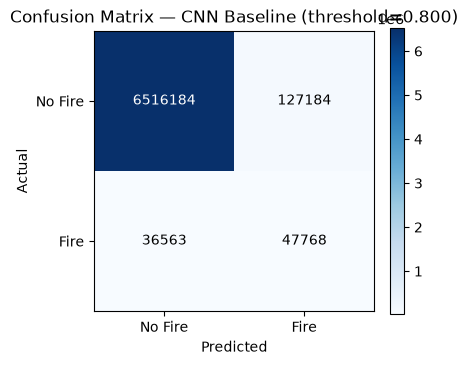

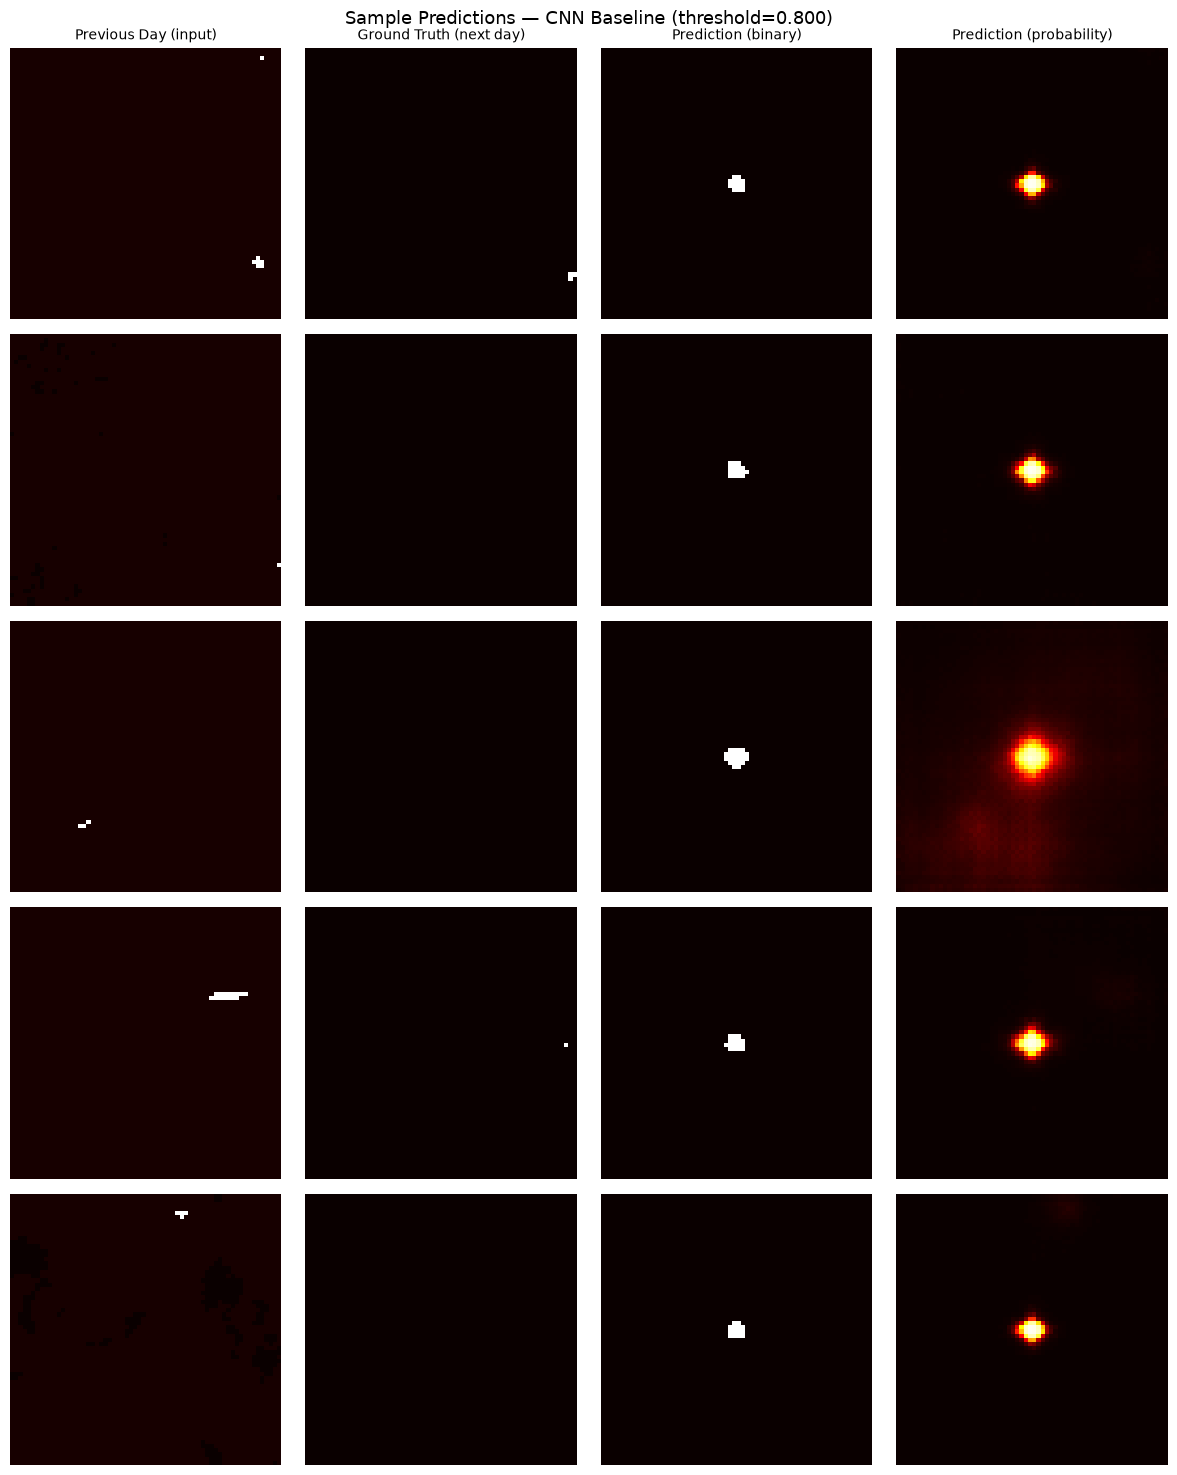

In [8]:
num_params = count_params(model)
TUNED_THRESHOLD = float(best_threshold_result["threshold"])

results = evaluate_model(
    model,
    test_loader,
    device,
    model_name="cnn_baseline",
    threshold=TUNED_THRESHOLD,
    training_time_sec=training_time_sec,
    num_params=num_params,
)

print(json.dumps(
    {key: value for key, value in results["metrics"].items() if key != "confusion_matrix"},
    indent=2,
))
print(f"Threshold: {TUNED_THRESHOLD:.3f}")
print(f"Params: {num_params:,} | Training time: {training_time_sec:.1f}s")

RESULTS_PATH = PROJECT_ROOT / "results" / "cnn_baseline_metrics_tuned_threshold.json"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
save_results(results, str(RESULTS_PATH))

plot_confusion_matrix(
    results["metrics"]["confusion_matrix"],
    model_name=f"CNN Baseline (threshold={TUNED_THRESHOLD:.3f})",
)
plot_prediction_grid(
    model,
    test_loader,
    device,
    model_name=f"CNN Baseline (threshold={TUNED_THRESHOLD:.3f})",
    n_samples=5,
    threshold=TUNED_THRESHOLD,
)

# Save the trained model checkpoint

In [9]:
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "cnn_baseline_best.pt"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": asdict(FINAL_CONFIG),
        "num_params": num_params,
        "test_metrics": results["metrics"],
    },
    CHECKPOINT_PATH,
)
print(f"Checkpoint saved to {CHECKPOINT_PATH}")

Checkpoint saved to c:\Users\Duvini\Documents\GitHub\Wildfire-Spread-Prediction-from-Satellite-Imagery\checkpoints\cnn_baseline_best.pt
